## Polars

[Polars](https://pola.rs/) es una librería de Python orientada a la **manipulación y análisis de datos tabulares**. Su API está pensada para trabajar de manera clara y eficiente con tablas, selecciones, filtros, agregaciones y transformaciones de columnas.

Las dos estructuras más importantes son:

* `DataFrame`: una tabla bidimensional con filas y columnas.
* `Series`: una estructura unidimensional que representa una columna o el resultado de una operación sobre una columna.


- https://polarsguide.com/
- https://docs.pola.rs/
- https://franzdiebold.github.io/polars-cheat-sheet/Polars_cheat_sheet.pdf

# Trabajar con datos

A lo largo del resto de esta clase vamos a trabajar con un conjunto de datos llamado **Gapminder**.

Este conjunto reúne indicadores demográficos y económicos observados para distintos países a lo largo del tiempo. Cada fila corresponde a un país en un año determinado, y las columnas contienen medidas como esperanza de vida, fecundidad, población y PIB.


## Leer datos tabulares

La lectura de datos es una de las tareas fundamentales en el análisis de datos. En Polars, muchas funciones para importar datos comienzan con `read_` y devuelven un `DataFrame`.

Algunos ejemplos son:

* `pl.read_csv()`
* `pl.read_excel()`
* `pl.read_json()`
* `pl.read_database()`


Los archivos CSV (valores separados por comas) son uno de los formatos más comunes para almacenar datos tabulares. En este caso, los datos están en `gapminder.csv`. Vamos a usar `pl.read_csv()` para leerlos.


In [1]:
import polars as pl

datos = pl.read_csv("gapminder.csv")

In [2]:
datos

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10
…,…,…,…,…,…,…
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9


In [3]:
type(datos)

polars.dataframe.frame.DataFrame

**Descripción de los datos**

| Columna | Descripción |
| --- | --- |
| `pais` | Nombre del país o territorio. |
| `año` | Año al que corresponde la observación. |
| `mortalidad_infantil` | Muertes de niños durante el primer año de vida por cada 1000 nacidos vivos. |
| `esperanza_de_vida` | Cantidad de años que viviría un recién nacido si las tasas de mortalidad por edad de ese momento se mantuvieran durante toda su vida. |
| `fecundidad` | Cantidad de hijos que tendría una mujer a lo largo de su vida si se mantuvieran las tasas de fecundidad por edad del año observado. |
| `poblacion` | Cantidad total de habitantes del territorio. |
| `pib` | Producto interno bruto total estimado a partir del PIB per cápita ajustado por paridad de poder adquisitivo, multiplicado por la población. |

El conjunto de datos que vamos a utilizar sigue los principios del [Tidy Data](https://es.wikipedia.org/wiki/Tidy_data) que dicen que:

* Cada **variable** es una **columna**.
* Cada **observación** es una **fila**.


Un `DataFrame` tiene los métodos `.head()` y `.tail()` que nos devuelven las primeras y últimas filas respectivamente. Esto es útil para realizar una exploración rápida de los primeros y últimos registros cargados.

In [4]:
datos.head()

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10


In [5]:
datos.tail()

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9
"""Zambia""",2024,null,61.69,4.04,21314956,7.9207e10
"""Zimbabue""",2024,null,66.62,3.67,16634373,5.7391e10


Los números que aparecen a la izquierda cuando se imprime la tabla sirven solo como referencia visual de las filas. En Polars no forman parte de una columna especial del `DataFrame`.

Tanto `.head()` como `.tail()` tienen un argumento llamado `n` que determina cuántas filas se seleccionan.


In [6]:
datos.head(2)

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9


In [7]:
datos.tail(7)

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Vanuatu""",2024,null,70.5,3.57,327777,1.0388e9
"""Venezuela""",2024,null,72.0,2.08,28405543,2.4306e11
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9
"""Zambia""",2024,null,61.69,4.04,21314956,7.9207e10
"""Zimbabue""",2024,null,66.62,3.67,16634373,5.7391e10


También podemos inspeccionar la estructura del `DataFrame` con varios atributos y métodos. En los siguientes bloques miramos el esquema (`schema`), los tipos de datos (`dtypes`), la cantidad de filas y columnas (`shape`) y el número de valores nulos por columna (`null_count()`).


In [8]:
datos.schema

Schema([('pais', String),
        ('año', Int64),
        ('mortalidad_infantil', Float64),
        ('esperanza_de_vida', Float64),
        ('fecundidad', Float64),
        ('poblacion', Int64),
        ('pib', Float64)])

In [9]:
datos.dtypes

[String, Int64, Float64, Float64, Float64, Int64, Float64]

In [10]:
datos.shape

(12675, 7)

In [11]:
datos.null_count()

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
u32,u32,u32,u32,u32,u32,u32
0,0,2934,66,0,24,130


Entre otras cosas obtenemos los **tipos de datos** y la **cantidad de valores faltantes** por columna.

En este conjunto hay columnas con datos ausentes. En Polars conviene distinguir entre `null` y `NaN`: `.drop_nans()` elimina filas que contienen `NaN` en columnas numéricas, mientras que `.drop_nulls()` elimina filas con valores `null`.


In [12]:
datos.describe()

statistic,pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,str,f64,f64,f64,f64,f64,f64
"""count""","""12675""",12675.0,9741.0,12609.0,12675.0,12651.0,12545.0
"""null_count""","""0""",0.0,2934.0,66.0,0.0,24.0,130.0
"""mean""",null,1992.0,55.176263,65.794942,3.904084,2.8173e7,3.6579e11
"""std""",null,18.762403,47.712243,10.385472,2.028995,1.1163e8,1.5291e12
"""min""","""Afganistan""",1960.0,1.5,11.1,0.72,651.0,1.1488e7
"""25%""",null,1976.0,16.1,58.9,2.03,1.159821e6,6.8366e9
"""50%""",null,1992.0,41.4,68.2,3.43,5.231654e6,3.4932e10
"""75%""",null,2008.0,84.3,73.5,5.84,1.69084e7,1.6807e11
"""max""","""Zimbabue""",2024.0,276.9,86.3,8.86,1.4509e9,3.3845e13


In [13]:
datos.drop_nans()

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10
…,…,…,…,…,…,…
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9


In [14]:
datos.drop_nulls()

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10
"""Arabia Saudita""",1960,150.0,43.8,7.52,2435403,2.7209e10
…,…,…,…,…,…,…
"""Vietnam""",2015,17.3,75.1,2.1,92823254,8.5843e11
"""Yemen""",2015,33.8,69.6,4.62,31159379,6.8454e10
"""Yibuti""",2015,54.2,66.4,3.04,1020313,5.0627e9


* ¿Cuántas observaciones seleccionamos?
* ¿Qué significa?

## Calcular agregaciones

A la hora de trabajar con datos, suele ser de interés procesarlos de alguna manera para obtener información respecto de algunas variables relevantes. Por ejemplo, se pueden calcular valores medios, mínimos, máximos, medianas, diferencias, razones, etc. Las cuentas que resumen muchos datos en un único valor se llaman **agregaciones** (porque se están agregando varios valores de alguna forma en un único valor).

### Agregaciones simples

Una forma muy rápida de calcular estadísticas básicas con un `DataFrame` es utilizar el método `.describe()`.

El método `.describe()` genera estadísticas básicas para las columnas numéricas del conjunto de datos.

In [15]:
datos.describe(percentiles=[0.1, 0.4, 0.6, 0.9])

statistic,pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,str,f64,f64,f64,f64,f64,f64
"""count""","""12675""",12675.0,9741.0,12609.0,12675.0,12651.0,12545.0
"""null_count""","""0""",0.0,2934.0,66.0,0.0,24.0,130.0
"""mean""",null,1992.0,55.176263,65.794942,3.904084,2.8173e7,3.6579e11
"""std""",null,18.762403,47.712243,10.385472,2.028995,1.1163e8,1.5291e12
"""min""","""Afganistan""",1960.0,1.5,11.1,0.72,651.0,1.1488e7
"""10%""",null,1966.0,7.1,49.9,1.54,122805.0,1.0632e9
"""40%""",null,1986.0,28.2,65.0,2.74,3.431932e6,2.0877e10
"""60%""",null,1998.0,55.3,70.6,4.37,8.323253e6,5.9911e10
"""90%""",null,2018.0,125.8,77.6,6.82,5.216221e7,6.9851e11


Por otro lado, si queremos calcular la cantidad de ocurrencias de una columna categórica o discreta, podemos utilizar `.value_counts()`.


In [16]:
datos["pais"].value_counts() # cuenta cuantas veces aparece cada valor

pais,count
str,u32
"""Australia""",65
"""San Marino""",65
"""Tayikistan""",65
"""Indonesia""",65
"""Alemania""",65
…,…
"""Jamaica""",65
"""Mauritania""",65
"""Letonia""",65


In [17]:
datos["año"].value_counts(sort=True)

año,count
i64,u32
1960,195
1961,195
1962,195
1963,195
1964,195
…,…
2020,195
2021,195
2022,195


El argumento `normalize` nos permite obtener la proporción que representa cada categoría.


In [18]:
datos["pais"].value_counts(normalize=True)

pais,proportion
str,f64
"""Cisjordania y Gaza""",0.005128
"""Chile""",0.005128
"""Guatemala""",0.005128
"""Libia""",0.005128
"""Kiribati""",0.005128
…,…
"""Tayikistan""",0.005128
"""Espana""",0.005128
"""Granada""",0.005128


Para contar combinaciones de dos o más columnas, en Polars suele resultar más claro agrupar con `.group_by(...).len()`.


In [19]:
datos.group_by("pais").len()

pais,len
str,u32
"""Reino Unido""",65
"""China""",65
"""Chipre""",65
"""Kuwait""",65
"""Libano""",65
…,…
"""Albania""",65
"""Ghana""",65
"""Tuvalu""",65


In [20]:
datos.group_by(("pais", "año")).len()

pais,año,len
str,i64,u32
"""Marruecos""",2017,1
"""Arabia Saudita""",1992,1
"""Dinamarca""",1986,1
"""Republica Centroafricana""",1995,1
"""Eritrea""",1965,1
…,…,…
"""Pakistan""",1963,1
"""Papua Nueva Guinea""",1964,1
"""Somalia""",1971,1


In [21]:
datos.group_by(("pais", "año")).len("cantidad")

pais,año,cantidad
str,i64,u32
"""Noruega""",1983,1
"""Guatemala""",1985,1
"""Portugal""",1967,1
"""Corea del Norte""",1978,1
"""Samoa""",1978,1
…,…,…
"""Oman""",2022,1
"""Bosnia y Herzegovina""",1993,1
"""Sudafrica""",2024,1


Otro método interesante es `.n_unique()`. Permite obtener la cantidad de valores únicos de una columna.


In [22]:
datos["pais"].n_unique() # cuantos valores unicos

195

In [23]:
datos["pais"].unique() # que valores unicos hay

pais
str
"""Corea del Sur"""
"""Turkmenistan"""
"""Monaco"""
"""Estados Unidos"""
"""India"""
…
"""Australia"""
"""Polonia"""
"""Niger"""


In [24]:
datos["pais"].n_unique()

195

En cuanto a las agregaciones de variables numéricas, podemos pensar en cualquier resumen estadístico de los usuales.

In [25]:
datos["fecundidad"].mean()

3.904083629191324

In [26]:
type(datos["fecundidad"].mean())

float

In [27]:
print(datos["esperanza_de_vida"].mean())
print(datos["esperanza_de_vida"].median())
print(datos["esperanza_de_vida"].std()) # desvio estándar
print(datos["esperanza_de_vida"].min())
print(datos["esperanza_de_vida"].max())
print(datos["esperanza_de_vida"].quantile(0.1))

65.79494170830355
68.2
10.385471629608203
11.1
86.3
49.9


### Agregaciones agrupadas

Cuando hablamos de agregaciones agrupadas nos referimos a calcular medidas resumen para cada grupo de filas.

Por ejemplo:

* ¿Cuál es la esperanza de vida promedio para cada año?
* ¿Qué país alcanza la mayor esperanza de vida registrada?
* ¿Cómo cambian la fecundidad y el PIB promedio cuando agrupamos por país?

Lo primero que tenemos que conocer para esto es el método `.group_by()`.

Este método agrupa el `DataFrame` según una o más columnas para que luego podamos aplicar agregaciones sobre cada grupo.


In [28]:
datos.group_by("año")

La representación del objeto agrupado es bastante austera, pero una vez agrupados los datos podemos aplicar agregaciones con `.agg()`.

Por ejemplo, si queremos calcular la esperanza de vida promedio para cada año:


In [29]:
datos.group_by("año").agg(pl.col("esperanza_de_vida").mean()).sort("año")

año,esperanza_de_vida
i64,f64
1960,56.193814
1961,56.610825
1962,57.12268
1963,57.465464
1964,57.841753
…,…
2020,72.032474
2021,71.128351
2022,72.752062


o la esperanza de vida máxima para cada país:


In [30]:
datos.group_by("pais").agg(pl.col("esperanza_de_vida").max()).sort("pais")

pais,esperanza_de_vida
str,f64
"""Afganistan""",68.81
"""Albania""",79.8
"""Alemania""",81.3
"""Andorra""",84.1
"""Angola""",64.5
…,…
"""Vietnam""",76.2
"""Yemen""",71.8
"""Yibuti""",68.61


In [33]:
datos.group_by("pais").agg(
    pl.col("fecundidad").mean(), 
    pl.col("pib").mean(),
).sort("pais")

pais,fecundidad,pib
str,f64,f64
"""Afganistan""",6.966,4.5795e10
"""Albania""",3.137077,2.1154e10
"""Alemania""",1.605231,3.2044e12
"""Andorra""",1.687692,2.8089e9
"""Angola""",6.752,1.0713e11
…,…,…
"""Vietnam""",3.644923,3.6938e11
"""Yemen""",6.969077,4.2767e10
"""Yibuti""",5.177231,2.5013e9


In [32]:
datos.group_by("pais").agg(
    f_media=pl.col("fecundidad").mean(), 
    pib_media=pl.col("pib").mean(),
).sort("pais")

pais,f_media,pib_media
str,f64,f64
"""Afganistan""",6.966,4.5795e10
"""Albania""",3.137077,2.1154e10
"""Alemania""",1.605231,3.2044e12
"""Andorra""",1.687692,2.8089e9
"""Angola""",6.752,1.0713e11
…,…,…
"""Vietnam""",3.644923,3.6938e11
"""Yemen""",6.969077,4.2767e10
"""Yibuti""",5.177231,2.5013e9


## Guardar datos tabulares

Así como tenemos diversas funciones para leer datos que dependen del tipo de archivo, también tenemos métodos para exportar los resultados.

Uno de los formatos más populares es el CSV. Para guardar un `DataFrame` de Polars como CSV usamos el método `.write_csv()`.

El primer argumento es la ruta donde se guardará el archivo.


In [ ]:
datos.write_csv

In [ ]:
datos.write_csv("salida.csv")

Como Polars no maneja un índice persistente, el archivo se guarda solo con las columnas presentes en el `DataFrame`.


In [ ]:
datos.head(10).write_csv("primeras_10_filas.csv")

Por ejemplo, podemos guardar una tabla con la cantidad de observaciones disponibles para cada año.


In [ ]:
df_cantidad = datos.group_by("año").len("cantidad").sort("año")
df_cantidad


In [ ]:
df_cantidad.write_csv("cantidad_por_año.csv")


# Manipulación de datos con Polars


In [34]:
datos.head()

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10


## Filtros

Cuando hablamos de filtros nos hacemos las siguiente preguntas:

* ¿Cómo seleccionamos un subconjunto de columnas?
* ¿Cómo seleccionamos un subconjunto de filas? ¿En base a qué regla?
* ¿Y cómo selecciono un subconjunto de filas y columnas a la vez?


### Filtrar columnas

Podemos seleccionar una columna de un `DataFrame` pasando el nombre de la misma dentro de corchetes (de la misma forma que haríamos con un diccionario).

In [43]:
datos["pais"].unique().sort()

pais
str
"""Afganistan"""
"""Albania"""
"""Alemania"""
"""Andorra"""
"""Angola"""
…
"""Vietnam"""
"""Yemen"""
"""Yibuti"""


In [45]:
paises = datos["pais"].unique()
type(paises)

polars.series.series.Series

**¡Importante!**

* El resultado es una `Series`, no un `DataFrame` compuesto por una sola columna.

* Si queremos que el resultado sea un `DataFrame` podemos utilizar una lista o una tupla en la selección.
    + Esto también nos permite seleccionar mas de una columna.

Ahora hagamos la misma selección, pero pasemos el nombre dentro de una lista:

In [47]:
datos.select("pais")

pais
str
"""Afganistan"""
"""Albania"""
"""Alemania"""
"""Andorra"""
"""Angola"""
…
"""Vietnam"""
"""Yemen"""
"""Yibuti"""


In [48]:
datos.select(["pais"])

pais
str
"""Afganistan"""
"""Albania"""
"""Alemania"""
"""Andorra"""
"""Angola"""
…
"""Vietnam"""
"""Yemen"""
"""Yibuti"""


In [50]:
datos.select("pais", "año", "pib")

pais,año,pib
str,i64,f64
"""Afganistan""",1960,2.0579e10
"""Albania""",1960,4.7802e9
"""Alemania""",1960,1.0928e12
"""Andorra""",1960,2.0938e8
"""Angola""",1960,1.7260e10
…,…,…
"""Vietnam""",2024,1.4558e12
"""Yemen""",2024,6.9188e10
"""Yibuti""",2024,7.9954e9


In [51]:
type(datos.select("pais", "año", "pib"))

polars.dataframe.frame.DataFrame

Al utilizar una lista (u otro tipo de secuencia similar) podemos seleccionar múltiples columnas de un `DataFrame`, obteniendo otro `DataFrame` pero con menos columnas.

### Filtrar filas

Ya vimos que para filtrar columnas pasamos el nombre de la columna o el nombre de varias columnas dentro de corchetes. Ahora: ¿cómo filtrar filas?, ¿en base a qué cosa las filtramos?

Una manera de filtrar filas es a partir de una **condición que determina qué filas conservamos**.

Por ejemplo, podemos querer quedarnos solo con las filas de Argentina. Veamos cómo se hace:


In [52]:
datos.filter(pl.col("pais") == "Argentina")

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Argentina""",1960,59.87,65.2,3.13,20386045,2.3537e11
"""Argentina""",1961,59.73,65.5,3.12,20726276,2.4924e11
"""Argentina""",1962,59.59,65.6,3.12,21072538,2.4672e11
"""Argentina""",1963,59.39,65.6,3.1,21421705,2.3963e11
"""Argentina""",1964,59.25,65.7,3.07,21769453,2.6202e11
…,…,…,…,…,…,…
"""Argentina""",2020,null,76.4,1.6,45191965,1.0791e12
"""Argentina""",2021,null,74.6,1.59,45312281,1.1917e12
"""Argentina""",2022,null,76.3,1.48,45407904,1.2545e12


In [53]:
datos.filter(pl.col("pais") != "Argentina")

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10
…,…,…,…,…,…,…
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9


In [54]:
datos.filter(pl.col("pais") == "Argentina", pl.col("año") >= 2000)

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Argentina""",2000,18.0,74.2,2.59,37213984,8.1167e11
"""Argentina""",2001,17.6,74.3,2.53,37624825,7.7803e11
"""Argentina""",2002,17.1,74.3,2.49,38029349,6.9509e11
"""Argentina""",2003,16.6,74.3,2.45,38424282,7.5838e11
"""Argentina""",2004,16.0,74.8,2.43,38815916,8.2873e11
…,…,…,…,…,…,…
"""Argentina""",2020,null,76.4,1.6,45191965,1.0791e12
"""Argentina""",2021,null,74.6,1.59,45312281,1.1917e12
"""Argentina""",2022,null,76.3,1.48,45407904,1.2545e12


¿Qué acabamos de usar? Comparaciones lógicas.

¿Cómo funciona? Mejor ver...


Ahora, ¿cómo podemos hacer para conservar filas de 2 países?

Una forma es usar el método `.is_in()`.

Por ejemplo, supongamos que queremos conservar Argentina y Brasil.


In [ ]:
datos.filter(pl.col("pais").is_in(["Argentina", "Brasil"]))

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Argentina""",1960,59.87,65.2,3.13,20386045,2.3537e11
"""Brasil""",1960,129.4,57.5,6.09,72388126,2.9743e11
"""Argentina""",1961,59.73,65.5,3.12,20726276,2.4924e11
"""Brasil""",1961,126.1,57.8,6.06,74605447,3.2655e11
"""Argentina""",1962,59.59,65.6,3.12,21072538,2.4672e11
…,…,…,…,…,…,…
"""Brasil""",2022,null,76.1,1.63,210306415,3.9020e12
"""Argentina""",2023,null,77.6,1.5,45538401,1.2343e12
"""Brasil""",2023,null,76.9,1.62,211140729,4.0285e12


In [57]:
datos.filter(
    pl.col("pais").is_in(["Argentina", "Brasil"]),
    pl.col("año").is_between(2000, 2010)
)

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Argentina""",2000,18.0,74.2,2.59,37213984,8.1167e11
"""Brasil""",2000,28.1,72.4,2.25,174018282,2.4149e12
"""Argentina""",2001,17.6,74.3,2.53,37624825,7.7803e11
"""Brasil""",2001,26.1,72.7,2.16,176301203,2.4543e12
"""Argentina""",2002,17.1,74.3,2.49,38029349,6.9509e11
…,…,…,…,…,…,…
"""Brasil""",2008,16.2,74.7,1.82,190367302,3.2603e12
"""Argentina""",2009,13.4,75.8,2.4,40854831,1.0503e12
"""Brasil""",2009,15.4,74.8,1.8,192079951,3.2555e12


In [59]:
datos.filter(
    (pl.col("año") < 2000) | (pl.col("año") > 2010)
)

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10
…,…,…,…,…,…,…
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9


Cuidado...

```python
datos.filter(
    pl.col("año") < 2000 | pl.col("año") > 2010
)
```

Filtro por grupo...

En el siguiente ejemplo, para cada país conservamos las filas donde la fecundidad coincide con el valor máximo observado dentro de ese país.


In [70]:
datos.filter(
    pl.col("fecundidad") == pl.col("fecundidad").max().over("pais")
)

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Antigua y Barbuda""",1960,null,63.1,4.56,55603,2.7807e8
"""Armenia""",1960,null,61.3,4.73,1863705,1.2421e10
"""Barbados""",1960,69.5,65.2,4.61,230893,1.4369e9
"""Barein""",1960,134.5,55.7,7.22,165477,1.3629e9
…,…,…,…,…,…,…
"""Santa Sede""",2020,null,null,1.0,null,null
"""Santa Sede""",2021,null,null,1.0,null,null
"""Santa Sede""",2022,null,null,1.0,null,null


In [69]:
datos.filter(
    pl.col("fecundidad") == pl.col("fecundidad").max().over("pais")
).group_by("pais").first().sort("pais")

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1994,107.7,59.5,7.77,16250794,1.8327e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1963,null,70.0,2.52,74698010,1.2086e12
"""Andorra""",1972,null,75.8,2.91,22957,1.1817e9
"""Angola""",1973,null,44.2,7.5,6388528,3.5026e10
…,…,…,…,…,…,…
"""Vietnam""",1963,67.3,55.4,6.4,35249101,5.6970e10
"""Yemen""",1985,106.2,57.5,8.86,11453825,2.6506e10
"""Yibuti""",1969,null,56.3,6.88,136078,8.2003e8


### Filtrar filas y columnas

Hasta ahora vimos como realizar cada una de estas operaciones por separado. En la práctica, muchas veces queremos filtrar tanto filas como columnas al mismo tiempo.

In [73]:
datos.filter(
    pl.col("fecundidad") > 2,
    pl.col("año") == 2024,
).select("pais", "pib")

pais,pib
str,f64
"""Afganistan""",8.6853e10
"""Angola""",2.7824e11
"""Arabia Saudita""",2.1287e12
"""Argelia""",7.2291e11
"""Banglades""",1.4730e12
…,…
"""Venezuela""",2.4306e11
"""Yemen""",6.9188e10
"""Yibuti""",7.9954e9


In [76]:
datos[0:10]

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10
"""Antigua y Barbuda""",1960,null,63.1,4.56,55603,2.7807e8
"""Arabia Saudita""",1960,150.0,43.8,7.52,2435403,2.7209e10
"""Argelia""",1960,148.2,40.1,7.54,11424922,5.5038e10
"""Argentina""",1960,59.87,65.2,3.13,20386045,2.3537e11


In [75]:
datos[0:10:2]

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10
"""Arabia Saudita""",1960,150.0,43.8,7.52,2435403,2.7209e10
"""Argentina""",1960,59.87,65.2,3.13,20386045,2.3537e11


In [78]:
datos[0:10:2, 0:3]

pais,año,mortalidad_infantil
str,i64,f64
"""Afganistan""",1960,245.0
"""Alemania""",1960,34.0
"""Angola""",1960,208.0
"""Arabia Saudita""",1960,150.0
"""Argentina""",1960,59.87


### Seleccionar combinaciones únicas / eliminar duplicados

En Polars podemos usar el método `.unique()` para quedarnos con combinaciones únicas de una o más columnas.

Esto sirve tanto para explorar valores posibles como para descartar filas duplicadas según un subconjunto de variables.


In [79]:
datos.head()

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10


Si usamos `subset`, Polars determina duplicados solo con esas columnas.

Por ejemplo, en los siguientes bloques pedimos las combinaciones únicas de `año`, y luego de `pais` con `año`.


In [83]:
datos.unique(subset=["año"])

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1971,202.2,55.0,7.43,11567667,2.8228e10
"""Afganistan""",1986,140.2,48.0,7.55,11420074,3.6569e10
"""Afganistan""",1989,126.8,57.7,7.56,11874088,2.9350e10
"""Afganistan""",1980,166.1,51.4,7.64,13169311,2.9648e10
"""Afganistan""",1968,213.3,54.3,7.38,10756922,2.6360e10
…,…,…,…,…,…,…
"""Afganistan""",2018,null,66.3,5.33,36743039,1.0664e11
"""Afganistan""",2009,76.8,65.2,6.3,27466101,7.0240e10
"""Afganistan""",2024,null,68.81,4.76,42647492,8.6853e10


In [84]:
datos.unique(subset=["pais", "año"])

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Paraguay""",1978,51.6,70.0,5.04,2899269,1.6315e10
"""Jamaica""",2000,18.7,74.4,2.35,2607826,2.4514e10
"""Costa de Marfil""",2004,91.4,54.9,5.53,19595000,7.8126e10
"""Tunez""",1969,128.4,54.9,6.62,5004697,1.4332e10
"""Letonia""",1967,null,71.0,1.82,2296079,2.7517e10
…,…,…,…,…,…,…
"""Ucrania""",1998,17.0,68.5,1.21,50379731,4.5046e11
"""Nepal""",1962,213.3,48.2,6.06,10521116,1.2372e10
"""Croacia""",2012,4.1,77.3,1.52,4259236,1.2037e11


## Crear, modificar y eliminar variables

Muy frecuentemente vamos a necesitar **crear**, **modificar** y **eliminar** variables cuando estemos analizando datos.

Veamos algunos ejemplos de situaciones donde esto puede ser interesante y cómo se hace.


### Crear nuevas variables





Echemos un vistazo a los datos:

In [86]:
datos.head(5)

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10


`pib` es una magnitud total y `poblacion` indica cuántas personas habitan cada país en cada año. Dos cuentas naturales son expresar el PIB en miles, o calcular el PIB por habitante dividiendo ambas columnas.

En los siguientes bloques hacemos esas dos operaciones.


In [87]:
datos["pib"] / 1000

pib
f64
2.0579e7
4.7802e6
1.0928e9
209377.505286
1.7260e7
…
1.4558e9
6.9188e7
7.9954e6


In [89]:
datos["pib"] / datos["poblacion"]

pib
f64
2277.64036
2898.16273
15008.53361
22016.56207
3299.10986
…
14415.21595
1704.843
6841.16653


In [90]:
datos.head()

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10


Esto **no guarda nada** en el `DataFrame` con el que estamos trabajando. Solo devuelve el resultado de la cuenta.

En Polars, para agregar o reemplazar columnas usamos `.with_columns()`. A continuación creamos una nueva variable llamada `pib_capita` a partir de dividir `pib` por `poblacion`.


In [91]:
datos.with_columns(
    pib_capita=pl.col("pib") / pl.col("poblacion")
)


TypeError: DataFrame object does not support `Series` assignment by index

Use `DataFrame.with_columns`.

In [92]:
datos.with_columns(
    (pl.col("pib") / pl.col("poblacion")).alias("pib_capita")
)


pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib,pib_capita
str,i64,f64,f64,f64,i64,f64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10,2277.64036
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9,2898.16273
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12,15008.53361
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8,22016.56207
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10,3299.10986
…,…,…,…,…,…,…,…
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12,14415.21595
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10,1704.843
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9,6841.16653


In [93]:
datos

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10
…,…,…,…,…,…,…
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9


In [ ]:
datos_mod = datos.with_columns(
    pib_capita=pl.col("pib") / pl.col("poblacion")
)
datos_mod


pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib,pib_capita
str,i64,f64,f64,f64,i64,f64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10,2277.64036
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9,2898.16273
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12,15008.53361
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8,22016.56207
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10,3299.10986
…,…,…,…,…,…,…,…
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12,14415.21595
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10,1704.843
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9,6841.16653


In [95]:
datos.with_columns(
    (pl.col("pib") / pl.col("poblacion")).alias("nuevo_nombre")
)


pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib,nuevo_nombre
str,i64,f64,f64,f64,i64,f64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10,2277.64036
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9,2898.16273
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12,15008.53361
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8,22016.56207
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10,3299.10986
…,…,…,…,…,…,…,…
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12,14415.21595
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10,1704.843
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9,6841.16653


In [96]:
datos.with_columns(
    (pl.col("pib") / pl.col("poblacion")).round().alias("nuevo_nombre")
)


pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib,nuevo_nombre
str,i64,f64,f64,f64,i64,f64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10,2278.0
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9,2898.0
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12,15009.0
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8,22017.0
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10,3299.0
…,…,…,…,…,…,…,…
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12,14415.0
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10,1705.0
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9,6841.0


### Modificar variables

Modificar una columna consiste en volver a calcularla y guardar el resultado con el mismo nombre.

En el siguiente bloque tomamos `esperanza_de_vida` y la expresamos en meses multiplicando por 12.


In [97]:
datos.head()

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10


In [99]:
datos.with_columns(
    (pl.col("esperanza_de_vida") * 12).alias("esperanza_de_vida")
)


pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,627.6,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,741.6,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,831.6,2.39,72811640,1.0928e12
"""Andorra""",1960,null,874.8,2.55,9510,2.0938e8
"""Angola""",1960,208.0,502.8,6.86,5231654,1.7260e10
…,…,…,…,…,…,…
"""Vietnam""",2024,null,914.4,1.9,100987686,1.4558e12
"""Yemen""",2024,null,861.6,4.5,40583164,6.9188e10
"""Yibuti""",2024,null,823.32,2.62,1168722,7.9954e9


De una manera similar, pero utilizando el método `.rename()` podemos cambiar el nombre a una o varias columnas.

Por ejemplo, en el siguiente bloque renombramos `mortalidad_infantil`, `pais` y `año`.


In [101]:
datos.rename({"mortalidad_infantil": "Mortalidad infantil", "pais": "País", "año": "Año"})


Pais,Año,Mortalidad infantil,esperanza_de_vida,fecundidad,poblacion,pib
str,i64,f64,f64,f64,i64,f64
"""Afganistan""",1960,245.0,52.3,7.38,9035043,2.0579e10
"""Albania""",1960,115.4,61.8,6.33,1649387,4.7802e9
"""Alemania""",1960,34.0,69.3,2.39,72811640,1.0928e12
"""Andorra""",1960,null,72.9,2.55,9510,2.0938e8
"""Angola""",1960,208.0,41.9,6.86,5231654,1.7260e10
…,…,…,…,…,…,…
"""Vietnam""",2024,null,76.2,1.9,100987686,1.4558e12
"""Yemen""",2024,null,71.8,4.5,40583164,6.9188e10
"""Yibuti""",2024,null,68.61,2.62,1168722,7.9954e9


### Eliminar variables

Para eliminar columnas tenemos el método `.drop()`. Simplemente le pasamos el nombre de las columnas que queremos descartar.

En el siguiente bloque descartamos las columnas `poblacion` y `pib`.


In [102]:
datos.drop("poblacion", "pib")

pais,año,mortalidad_infantil,esperanza_de_vida,fecundidad
str,i64,f64,f64,f64
"""Afganistan""",1960,245.0,52.3,7.38
"""Albania""",1960,115.4,61.8,6.33
"""Alemania""",1960,34.0,69.3,2.39
"""Andorra""",1960,null,72.9,2.55
"""Angola""",1960,208.0,41.9,6.86
…,…,…,…,…
"""Vietnam""",2024,null,76.2,1.9
"""Yemen""",2024,null,71.8,4.5
"""Yibuti""",2024,null,68.61,2.62


## Ordenar filas

Para ordenar las observaciones en base al valor de una variable podemos utilizar el método `.sort()`.

Le podemos pasar el nombre de una o más variables.

Si utilizamos una variable, podemos pasar directamente la cadena. Si utilizamos más de una, conviene pasarlas en una lista.


In [78]:
datos.sort("pais")


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_length_cm
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,masculino,3.91
97,Adelie,Dream,40.3,18.5,196.0,4350.0,masculino,4.03
98,Adelie,Dream,33.1,16.1,178.0,2900.0,femenino,3.31
99,Adelie,Dream,43.2,18.5,192.0,4100.0,masculino,4.32
100,Adelie,Biscoe,35.0,17.9,192.0,3725.0,femenino,3.50
...,...,...,...,...,...,...,...,...
253,Gentoo,Biscoe,55.9,17.0,228.0,5600.0,masculino,5.59
252,Gentoo,Biscoe,48.5,15.0,219.0,4850.0,femenino,4.85
251,Gentoo,Biscoe,51.1,16.5,225.0,5250.0,masculino,5.11
264,Gentoo,Biscoe,43.5,15.2,213.0,4650.0,femenino,4.35


Este método tiene un argumento llamado `descending`.

`descending` determina si ordenamos de manera descendente (de mayor a menor) o no.

Por defecto `descending` es `False`, es decir, el orden es ascendente.

Podemos probar con `descending=True`.


In [81]:
datos.sort("pais", descending=True)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_length_cm
172,Gentoo,Biscoe,50.2,14.3,218.0,5700.0,masculino,5.02
213,Gentoo,Biscoe,46.2,14.9,221.0,5300.0,masculino,4.62
222,Gentoo,Biscoe,47.7,15.0,216.0,4750.0,femenino,4.77
221,Gentoo,Biscoe,50.7,15.0,223.0,5550.0,masculino,5.07
220,Gentoo,Biscoe,43.5,14.2,220.0,4700.0,femenino,4.35
...,...,...,...,...,...,...,...,...
101,Adelie,Biscoe,41.0,20.0,203.0,4725.0,masculino,4.10
100,Adelie,Biscoe,35.0,17.9,192.0,3725.0,femenino,3.50
99,Adelie,Dream,43.2,18.5,192.0,4100.0,masculino,4.32
98,Adelie,Dream,33.1,16.1,178.0,2900.0,femenino,3.31


Ahora veamos un ejemplo donde ordenamos en base al país y el año.


In [85]:
datos.sort(["pais", "año"])


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_length_cm
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,femenino,3.95
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,femenino,4.03
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,femenino,3.67
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,femenino,3.89
12,Adelie,Torgersen,41.1,17.6,182.0,3200.0,femenino,4.11
...,...,...,...,...,...,...,...,...
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,4.45
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,4.62
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,4.73
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,4.45


Como Polars no usa un índice persistente, ordenar las filas no requiere ningún paso extra para reenumerarlas.

Si queremos numerarlas explícitamente después de ordenar, podemos agregar una columna con `.with_row_index()`.


In [ ]:
datos.sort(["pais", "año"]).with_row_index()


,index,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_length_cm
0,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.95
1,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,4.03
2,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.67
3,6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007,3.89
4,12,Adelie,Torgersen,41.1,17.6,182.0,3200.0,female,2007,4.11
...,...,...,...,...,...,...,...,...,...,...
339,178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007,4.45
340,218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008,4.62
341,256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009,4.73
342,268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009,4.45


In [87]:
datos_ordenados = datos.sort(["pais", "año"])
datos_ordenados


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_length_cm
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,femenino,3.95
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,femenino,4.03
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,femenino,3.67
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,femenino,3.89
12,Adelie,Torgersen,41.1,17.6,182.0,3200.0,femenino,4.11
...,...,...,...,...,...,...,...,...
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,4.45
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,4.62
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,4.73
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,4.45


Podemos combinar `.sort()` con `.unique()` para obtener combinaciones únicas de variables de una manera ordenada.

Por ejemplo:


In [91]:
datos.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [92]:
# 1. Creo una lista con las columnas a utilizar
# 2. Selecciono solo esas columnas
# 3. Elimino duplicados en base a ellas
# 4. Ordeno las filas en base a las columnas en `cols`
cols = ["pais", "año"]
datos.select(cols).unique().sort(cols)


,species,island,year
20,Adelie,Biscoe,2007
50,Adelie,Biscoe,2008
100,Adelie,Biscoe,2009
30,Adelie,Dream,2007
84,Adelie,Dream,2008
132,Adelie,Dream,2009
0,Adelie,Torgersen,2007
68,Adelie,Torgersen,2008
116,Adelie,Torgersen,2009
276,Chinstrap,Dream,2007


Podemos traducir el código a un lenguaje un poco más coloquial:

* Selecciona las columnas `"pais"` y `"año"`.
* Elimina duplicados en base a esas columnas.
* Ordena el resultado por `"pais"` y luego por `"año"`.


## Ejercicios


### Clase 4


#### Ejercicio 1

Responda las siguientes preguntas utilizando el conjunto de datos Palmer Penguins.

* ¿Cuál es el peso promedio para cada especie?
* ¿Cuál es el peso minimo para cada sexo?
* ¿Que especie presenta menor similitud en cuanto al tamaño de las aletas?
    * Para responder esto compare los desvíos estándar
* ¿En cuántas islas se realizaron las mediciones?
* ¿En qué isla se realizaron más mediciones?
* ¿Como se distribuyen las diferentes especies en las diferentes islas?
* ¿En qué rango se encuentra la longitud y profundidad del pico?

#### Ejercicio 2

¿Cuál es la diferencia entre los siguientes bloques de código?

In [ ]:
datos.groupby("species").mean()["body_mass_g"]

In [ ]:
datos.groupby("species")["body_mass_g"].mean()

#### Ejercicio 3

El conjunto de datos `mtcars` fue extraído de la revista estadounidense Motor Trend de 1974, y comprende el consumo de combustible y 10 aspectos del diseño y rendimiento automovilístico de 32 automóviles (modelos de 1973-74). Las variables se describen a continuación:

* `mpg`: Millas por galón (EE. UU.)
* `cyl`: Número de cilindros
* `disp`: Desplazamiento del motor (pulgadas cúbicas)
* `hp`: Caballos de fuerza brutos
* `drat`: Relación del eje trasero
* `wt`: Peso (1000 libras)
* `qsec`: Tiempo de recorrido de 1/4 de milla
* `vs`: Motor (0 = en forma de V, 1 = en línea)
* `am`: Transmisión (0 = automática, 1 = manual)
* `gear`: Número de marchas

Realice las siguientes tareas

* Cargue el conjunto de datos `mtcars.csv` con Pandas
* Muestre las primeras 10 filas
* Encuentre el peso del auto mas pesado y el del auto mas liviano (`wt`)
* Calcule el promedio de millas por galón (`mpg`)
    * Luego calcule el promedio de millas por galón según tipo de transmisión (`am`)
* Calcule el promedio de millas por galón según el número de marchas (`gear`) y el número de cilindros (`cyl`)

### Clase 5

#### Ejercicio 1

Modificar las etiquetas de los ejes horizontal y vertical del siguiente gráfico para que se muestren en español.

Ayuda: El método `g.legend(title="Nuevo titulo")` permite cambiar el título de la leyenda.

In [ ]:
datos = pd.read_csv("palmerpenguins.csv")
datos.head()

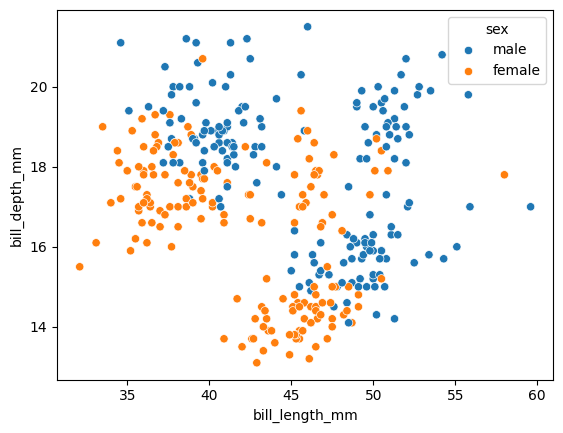

In [ ]:
g = sns.scatterplot(x="bill_length_mm", y="bill_depth_mm", hue="sex", data=datos)

#### Ejercicio 2

1. Mostrar un gráfico con la cantidad de pingüinos por sexo.
1. Utilizar `.value_counts()` para obtener el porcentaje de pingüinos por sexo y luego graficar utilizando `sns.barplot`

#### Ejercicio 3

**Parte 1**

1. Cargar los datos `mtcars.csv`
1. Renombrar los niveles de la variable `am` según su significado (0: automática, 1: manual)
1. Obtener un gráfico de barras que muestre la cantidad de vehículos según transmisión

**Parte 2**

1. Mostrar un histograma de la variable millas por galón
1. Obtener un boxplot de las millas por galón según la cantidad de marchas de los vehículos

**Parte 3**

1. Descarte los vehículos donde la cantidad de millas por galón es mayor a 30
1. Obtenga un gráfico de dispersión para observar la relación entre el peso y la cantidad de millas por galón de los vehículos
1. Coloree los puntos según el tipo de transmisión


**Parte 4**

Obtenga un pairplot donde observe la relación entre las siguientes variables

* `mpg`
* `hp`
* `wt`
* `qsec`

y coloree los puntos según la cantidad de cilindros.

Finalmente guarde la figura como un archivo `.png`.

---

## Ejercicio 1

Responda las siguientes preguntas utilizando el conjunto de datos Palmer Penguins.

* ¿Cuál es el peso promedio para cada especie?
* ¿Cuál es el peso minimo para cada sexo?
* ¿Que especie presenta menor similitud en cuanto al tamaño de las aletas?
    * Para responder esto compare los desvíos estándar
* ¿En cuántas islas se realizaron las mediciones?
* ¿En qué isla se realizaron más mediciones?
* ¿Como se distribuyen las diferentes especies en las diferentes islas?
* ¿En qué rango se encuentra la longitud y profundidad del pico?

## Ejercicio 3

El conjunto de datos `mtcars` fue extraído de la revista estadounidense Motor Trend de 1974, y comprende el consumo de combustible y 10 aspectos del diseño y rendimiento automovilístico de 32 automóviles (modelos de 1973-74). Las variables se describen a continuación:

* `mpg`: Millas por galón (EE. UU.)
* `cyl`: Número de cilindros
* `disp`: Desplazamiento del motor (pulgadas cúbicas)
* `hp`: Caballos de fuerza brutos
* `drat`: Relación del eje trasero
* `wt`: Peso (1000 libras)
* `qsec`: Tiempo de recorrido de 1/4 de milla
* `vs`: Motor (0 = en forma de V, 1 = en línea)
* `am`: Transmisión (0 = automática, 1 = manual)
* `gear`: Número de marchas

Realice las siguientes tareas

* Cargue el conjunto de datos `mtcars.csv` con Pandas
* Muestre las primeras 10 filas
* Encuentre el peso del auto mas pesado y el del auto mas liviano (`wt`)
* Calcule el promedio de millas por galón (`mpg`)
    * Luego calcule el promedio de millas por galón según tipo de transmisión (`am`)
* Calcule el promedio de millas por galón según el número de marchas (`gear`) y el número de cilindros (`cyl`)